In [1]:
# ==================== 自動處理「TRAIN 0-5」資料夾 ====================

from pathlib import Path
import pandas as pd

# 1. 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. 設定您的資料夾路徑（請確認路徑正確）
TRAIN_FOLDER = "/content/drive/MyDrive//Time-LLM-main/TRAIN 0-5"   # ← 如果資料夾名稱不同，請修改這裡

# 3. 自動掃描資料夾內所有 CSV 並合併成 train.csv
csv_files = list(Path(TRAIN_FOLDER).glob("*.csv"))

print(f"找到 {len(csv_files)} 個 CSV 檔案（資料夾：TRAIN 0-5）")

df_list = []
for file in csv_files:
    df = pd.read_csv(file)
    # 只保留需要的兩欄（您可以自行增加其他欄位）
    if 'disp_x_diff' in df.columns and 'disp_z_diff' in df.columns:
        df = df[['disp_x_diff', 'disp_z_diff']]
        df_list.append(df)
    else:
        print(f"警告：檔案 {file.name} 缺少 disp_x_diff 或 disp_z_diff 欄位，已跳過")

# 合併並儲存
train_df = pd.concat(df_list, ignore_index=True)
train_df.to_csv("/content/drive/MyDrive/train.csv", index=False)

print(f"✅ 合併完成！共 {len(train_df)} 筆資料，已儲存為 train.csv")
print(f"train.csv 路徑：/content/drive/MyDrive/train.csv")

Mounted at /content/drive
找到 43 個 CSV 檔案（資料夾：TRAIN 0-5）
✅ 合併完成！共 28462 筆資料，已儲存為 train.csv
train.csv 路徑：/content/drive/MyDrive/train.csv


In [2]:
from huggingface_hub import login

# 執行這段後，下方會出現一個對話框，請貼上你的 Hugging Face Access Token
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# ==================== Time-LLM + ACE 訓練  ====================

!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q transformers accelerate bitsandbytes

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from google.colab import drive

drive.mount('/content/drive')

# ====================== ACE + Time-LLM 模型 ======================
class ACE_Playbook:
    def __init__(self):
        self.playbook = []
    def generator(self, trend, top5_lags, expert_knowledge):
        return f"[ACE 動態上下文]\n趨勢：{trend}\n前五大滯後：{top5_lags}\n專家知識：{expert_knowledge}\n建議：溫度與壓力對位移影響大。"
    def curator(self, new_strategy):
        self.playbook.append(new_strategy)
        return self.playbook[-3:]

class TimeLLMWithACE(nn.Module):
    def __init__(self, V_prime=200):
        super().__init__()

        bnb_config = BitsAndBytesConfig(load_in_8bit=True)

        self.llm = AutoModelForCausalLM.from_pretrained(
            "meta-llama/Llama-2-7b-hf",
            torch_dtype=torch.float16,
            device_map="auto",
            quantization_config=bnb_config
        )
        self.tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")
        self.llm.eval()

        # 凍結 LLM 參數
        for param in self.llm.parameters():
            param.requires_grad = False

        # 【修改 1】自定義層保持預設的 float32，獲得最大的數值穩定空間
        self.patch_embedding = nn.Linear(2, V_prime)
        self.W = nn.Parameter(torch.empty(V_prime, self.llm.config.vocab_size))
        nn.init.xavier_uniform_(self.W)

        # 【核心修正 2】加入 LayerNorm，強制穩定進入 LLM 前的數值尺度
        self.reprogram_norm = nn.LayerNorm(self.llm.config.hidden_size)

        self.output_projection = nn.Linear(self.llm.config.hidden_size, 2)

        self.ace = ACE_Playbook()

    def forward(self, patches, trend, top5_lags, expert_knowledge):
        new_strategy = self.ace.generator(trend, top5_lags, expert_knowledge)
        self.ace.curator(new_strategy)

        prompt = f"[ACE 動態上下文]\n{new_strategy}\n請預測下一個時間步的位移變化。"
        batch_size = patches.shape[0]

        # 此時 patches 預設是 float32
        patch_emb = self.patch_embedding(patches)

        # 提取 LLM 的 Embedding 權重並轉為 float32 進行安全相乘
        llm_weight_fp32 = self.llm.get_input_embeddings().weight.to(torch.float32)
        E_prime = torch.matmul(self.W, llm_weight_fp32)

        # 取得重編程特徵 (float32)
        reprogrammed = torch.matmul(patch_emb, E_prime)

        # 【核心修正 3】套用 LayerNorm，將數值壓縮至安全範圍
        reprogrammed = self.reprogram_norm(reprogrammed)

        # 【修改 4】直到進入 LLM 的最後一刻，才將特徵降級為 float16
        reprogrammed = reprogrammed.to(torch.float16)

        inputs = self.tokenizer(prompt, return_tensors="pt").to(patch_emb.device)
        text_emb = self.llm.get_input_embeddings()(inputs.input_ids)
        text_emb = text_emb.expand(batch_size, -1, -1)

        inputs_embeds = torch.cat([reprogrammed, text_emb], dim=1)

        outputs = self.llm(inputs_embeds=inputs_embeds, output_hidden_states=True)

        hidden = outputs.hidden_states[-1]
        flat = hidden.mean(dim=1)

        # 轉回 float32 進行投影與 Loss 計算
        flat_fp32 = flat.to(torch.float32)
        return self.output_projection(flat_fp32)

class LatheDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)
        # 提取原始數值
        raw_data = torch.tensor(self.df[['disp_x_diff', 'disp_z_diff']].values, dtype=torch.float32)

        # 進行 Z-Score 正規化
        self.mean = raw_data.mean(dim=0)
        self.std = raw_data.std(dim=0)
        # 加上 1e-8 避免除以零的錯誤
        self.data = (raw_data - self.mean) / (self.std + 1e-8)

        self.seq_len = 16

    def __len__(self):
        return len(self.data) - self.seq_len + 1

    def __getitem__(self, idx):
        return self.data[idx : idx + self.seq_len]

# ====================== 訓練 ======================
def train():
    model = TimeLLMWithACE().cuda()
    # 修改 1：調降學習率至 1e-4
    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)

    train_loader = DataLoader(LatheDataset("/content/drive/MyDrive/train.csv"), batch_size=4, shuffle=True)

    print("開始訓練...")
    for epoch in range(20):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            trend = "upward" if batch.mean() > 0 else "downward"
            top5_lags = [1, 2, 3, 4, 5]
            expert = "車床位移受溫度與壓力影響顯著"

            pred = model(batch.cuda(), trend, top5_lags, expert)

            # 取最後一個時間步作為真實值
            target = batch[:, -1, :].cuda()
            loss = nn.MSELoss()(pred, target)

            loss.backward()

            # 修改 2：加入梯度裁剪，限制最大梯度為 1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1:2d} | Loss: {total_loss/len(train_loader):.4f}")

    torch.save(model.state_dict(), "/content/drive/MyDrive/time_llm_ace_144cu.pth")
    print("訓練完成，模型已儲存。")


train()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

開始訓練...
Epoch  1 | Loss: 0.8531
Epoch  2 | Loss: 0.6490
Epoch  3 | Loss: 0.5486
Epoch  4 | Loss: 0.4751
Epoch  5 | Loss: 0.4208
Epoch  6 | Loss: 0.3782
Epoch  7 | Loss: 0.3528
Epoch  8 | Loss: 0.3397
Epoch  9 | Loss: 0.3136
Epoch 10 | Loss: 0.2813
Epoch 11 | Loss: 0.2476
Epoch 12 | Loss: 0.2053
Epoch 13 | Loss: 0.1495
Epoch 14 | Loss: 0.1062
Epoch 15 | Loss: 0.0795
Epoch 16 | Loss: 0.0699
Epoch 17 | Loss: 0.0610
Epoch 18 | Loss: 0.0587
Epoch 19 | Loss: 0.0554
Epoch 20 | Loss: 0.0515
訓練完成，模型已儲存。


In [ ]:
# ==================== 自動處理「測試集」資料夾 ====================

from pathlib import Path
import pandas as pd
from google.colab import drive

# 1. 掛載 Google Drive (如果您剛剛已經掛載過，這步會自動略過)
drive.mount('/content/drive')

# 2. 設定您的「測試集」資料夾路徑
# ⚠️ 注意：請將最後面的 "TEST_FOLDER_NAME" 換成您實際放測試資料的資料夾名稱！
TEST_FOLDER = "/content/drive/MyDrive/Time-LLM-main/初賽測驗用數據"

# 3. 自動掃描資料夾內所有 CSV 並合併成 test.csv
csv_files = list(Path(TEST_FOLDER).glob("*.csv"))

print(f"🔍 準備掃描資料夾：{TEST_FOLDER}")
print(f"📂 共找到 {len(csv_files)} 個 CSV 檔案")

df_list = []
for file in csv_files:
    df = pd.read_csv(file)
    # 只保留需要的兩欄
    if 'disp_x_diff' in df.columns and 'disp_z_diff' in df.columns:
        df = df[['disp_x_diff', 'disp_z_diff']]
        df_list.append(df)
    else:
        print(f"⚠️ 警告：檔案 {file.name} 缺少 disp_x_diff 或 disp_z_diff 欄位，已跳過")

# 4. 合併並儲存
if len(df_list) > 0:
    test_df = pd.concat(df_list, ignore_index=True)
    test_df.to_csv("/content/drive/MyDrive/test.csv", index=False)
    print(f"✅ 測試集合併完成！共收集了 {len(test_df)} 筆資料。")
    print(f"💾 test.csv 已經成功儲存至：/content/drive/MyDrive/test.csv")
else:
    print("❌ 錯誤：找不到任何有效的 CSV 檔案，無法建立 test.csv。請確認您的資料夾路徑是否正確！")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 準備掃描資料夾：/content/drive/MyDrive/Time-LLM-main/初賽測驗用數據
📂 共找到 13 個 CSV 檔案
✅ 測試集合併完成！共收集了 8742 筆資料。
💾 test.csv 已經成功儲存至：/content/drive/MyDrive/test.csv


In [20]:

!pip install -q transformers accelerate "bitsandbytes>=0.46.
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q transformers accelerate bitsandbytes

/bin/bash: -c: line 1: unexpected EOF while looking for matching `"'
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [ ]:
import pandas as pd

# 讀取測試集
test_file_path = "/content/drive/MyDrive/test.csv"
df = pd.read_csv(test_file_path)

print(f"🧹 清理前資料筆數: {len(df)}")

# 強制將欄位轉為數值格式，如果遇到無法轉換的文字就變成 NaN
df['disp_x_diff'] = pd.to_numeric(df['disp_x_diff'], errors='coerce')
df['disp_z_diff'] = pd.to_numeric(df['disp_z_diff'], errors='coerce')

# 刪除所有包含 NaN (空值或壞資料) 的列
df_clean = df.dropna()

print(f"✨ 清理後資料筆數: {len(df_clean)}")
print(f"🗑️ 共剔除了 {len(df) - len(df_clean)} 筆異常資料")

# 覆蓋儲存回原本的檔案
df_clean.to_csv(test_file_path, index=False)
print("✅ 測試集清理完成！")

🧹 清理前資料筆數: 8742
✨ 清理後資料筆數: 1300
🗑️ 共剔除了 7442 筆異常資料
✅ 測試集清理完成！


🔄 準備載入模型與測試資料...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

 開始進行測試集推論...
🎯 測試集總結 (Test Evaluation)
✅ Average Test Loss (MSE): 0.0028


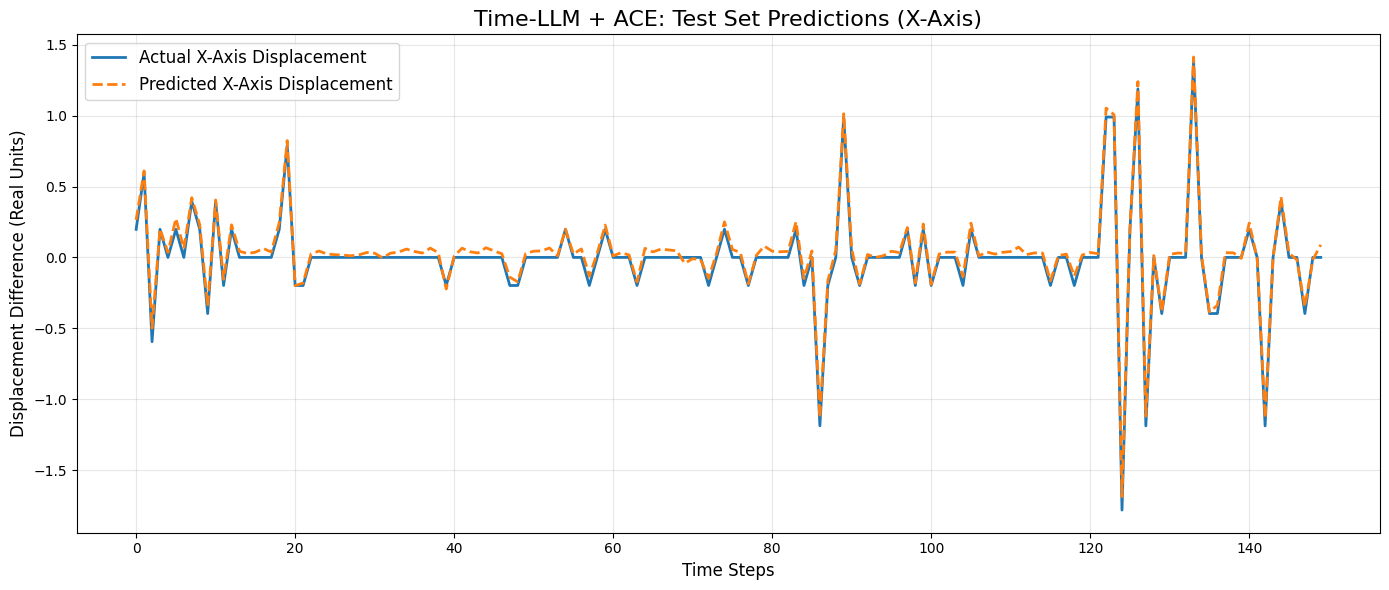

In [ ]:

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from google.colab import drive

# ================= 1. 定義依賴的類別 =================

class ACE_Playbook:
    def __init__(self):
        self.playbook = []
    def generator(self, trend, top5_lags, expert_knowledge):
        return f"[ACE 動態上下文]\n趨勢：{trend}\n前五大滯後：{top5_lags}\n專家知識：{expert_knowledge}\n建議：溫度與壓力對位移影響大。"
    def curator(self, new_strategy):
        self.playbook.append(new_strategy)
        return self.playbook[-3:]

class TimeLLMWithACE(nn.Module):
    def __init__(self, V_prime=200):
        super().__init__()
        bnb_config = BitsAndBytesConfig(load_in_8bit=True)
        self.llm = AutoModelForCausalLM.from_pretrained(
            "meta-llama/Llama-2-7b-hf",
            torch_dtype=torch.float16,
            device_map="auto",
            quantization_config=bnb_config
        )
        self.tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")
        self.llm.eval()

        for param in self.llm.parameters():
            param.requires_grad = False

        self.patch_embedding = nn.Linear(2, V_prime)
        self.W = nn.Parameter(torch.empty(V_prime, self.llm.config.vocab_size))
        nn.init.xavier_uniform_(self.W)
        self.reprogram_norm = nn.LayerNorm(self.llm.config.hidden_size)
        self.output_projection = nn.Linear(self.llm.config.hidden_size, 2)
        self.ace = ACE_Playbook()

    def forward(self, patches, trend, top5_lags, expert_knowledge):
        new_strategy = self.ace.generator(trend, top5_lags, expert_knowledge)
        self.ace.curator(new_strategy)
        prompt = f"[ACE 動態上下文]\n{new_strategy}\n請預測下一個時間步的位移變化。"
        batch_size = patches.shape[0]

        patch_emb = self.patch_embedding(patches)
        llm_weight_fp32 = self.llm.get_input_embeddings().weight.to(torch.float32)
        E_prime = torch.matmul(self.W, llm_weight_fp32)
        reprogrammed = torch.matmul(patch_emb, E_prime)
        reprogrammed = self.reprogram_norm(reprogrammed).to(torch.float16)

        inputs = self.tokenizer(prompt, return_tensors="pt").to(patch_emb.device)
        text_emb = self.llm.get_input_embeddings()(inputs.input_ids)
        text_emb = text_emb.expand(batch_size, -1, -1)

        inputs_embeds = torch.cat([reprogrammed, text_emb], dim=1)
        outputs = self.llm(inputs_embeds=inputs_embeds, output_hidden_states=True)

        hidden = outputs.hidden_states[-1]
        flat = hidden.mean(dim=1)
        return self.output_projection(flat.to(torch.float32))

class LatheDataset(Dataset):
    def __init__(self, csv_path, train_mean=None, train_std=None):
        self.df = pd.read_csv(csv_path)
        raw_data = torch.tensor(self.df[['disp_x_diff', 'disp_z_diff']].values, dtype=torch.float32)
        if train_mean is None or train_std is None:
            self.mean = raw_data.mean(dim=0)
            self.std = raw_data.std(dim=0)
        else:
            self.mean = train_mean
            self.std = train_std
        self.data = (raw_data - self.mean) / (self.std + 1e-8)
        self.seq_len = 16
    def __len__(self):
        return len(self.data) - self.seq_len + 1
    def __getitem__(self, idx):
        return self.data[idx : idx + self.seq_len]

# ================= 2. 測試與繪圖流程 =================

def run_test_evaluation():
    print("🔄 準備載入模型與測試資料...")
    model = TimeLLMWithACE().cuda()
    model.load_state_dict(torch.load("/content/drive/MyDrive//Time-LLM-main/time_llm_ace_144cu.pth"))
    model.eval()

    # 取出 train.csv 的正規化參數給 test.csv 用
    train_dataset = LatheDataset("/content/drive/MyDrive/train.csv")
    test_dataset = LatheDataset("/content/drive/MyDrive/test.csv",
                                train_mean=train_dataset.mean,
                                train_std=train_dataset.std)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

    print(" 開始進行測試集推論...")
    total_test_loss = 0
    actuals_x, preds_x = [], []

    with torch.no_grad():
        for batch in test_loader:
            trend = "upward" if batch.mean() > 0 else "downward"
            top5_lags = [1, 2, 3, 4, 5]
            expert = "車床位移受溫度與壓力影響顯著"

            pred = model(batch.cuda(), trend, top5_lags, expert)
            target = batch[:, -1, :].cuda()

            loss = nn.MSELoss()(pred, target)
            total_test_loss += loss.item()

            std_x = train_dataset.std[0].item()
            mean_x = train_dataset.mean[0].item()

            for i in range(pred.shape[0]):
                real_x = target[i][0].item() * std_x + mean_x
                pred_x = pred[i][0].item() * std_x + mean_x
                actuals_x.append(real_x)
                preds_x.append(pred_x)

    avg_test_loss = total_test_loss / len(test_loader)
    print("="*40)
    print(f"🎯 測試集總結 (Test Evaluation)")
    print(f"✅ Average Test Loss (MSE): {avg_test_loss:.4f}")
    print("="*40)

    # 繪圖
    plot_limit = min(150, len(actuals_x))
    plt.figure(figsize=(14, 6))
    plt.plot(actuals_x[:plot_limit], label="Actual X-Axis Displacement", color='#1f77b4', linewidth=2)
    plt.plot(preds_x[:plot_limit], label="Predicted X-Axis Displacement", color='#ff7f0e', linestyle='--', linewidth=2)
    plt.title("Time-LLM + ACE: Test Set Predictions (X-Axis)", fontsize=16)
    plt.xlabel("Time Steps", fontsize=12)
    plt.ylabel("Displacement Difference (Real Units)", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 執行
run_test_evaluation()

In [ ]:
import torch
import pandas as pd

# ==========================================
# 實戰預測工具 (修正資料型態版本)
# ==========================================

class LathePredictor:
    def __init__(self, model_path, train_csv_path):
        print("啟動預測引擎中...")
        # 1. 載入模型架構與權重
        self.model = TimeLLMWithACE().cuda()
        self.model.load_state_dict(torch.load(model_path))
        self.model.eval()

        # 2. 載入正規化參數
        train_df = pd.read_csv(train_csv_path)
        raw_data = torch.tensor(train_df[['disp_x_diff', 'disp_z_diff']].values, dtype=torch.float32)
        self.mean = raw_data.mean(dim=0).cuda()
        self.std = raw_data.std(dim=0).cuda()

        print("預測引擎啟動完成，準備接收數據。")

    def predict(self, recent_16_data, expert_knowledge="機台運作正常"):
        """
        輸入:
        1. recent_16_data: 過去 16 個時間步的真實數據
        2. expert_knowledge: 動態上下文提示
        """
        # 1. 轉換為 Tensor (保持 float32)
        if isinstance(recent_16_data, pd.DataFrame):
            input_tensor = torch.tensor(recent_16_data[['disp_x_diff', 'disp_z_diff']].values, dtype=torch.float32).cuda()
        else:
            input_tensor = torch.tensor(recent_16_data, dtype=torch.float32).cuda()

        input_tensor = input_tensor.unsqueeze(0)

        # 2. Z-Score 正規化
        normalized_input = (input_tensor - self.mean) / (self.std + 1e-8)

        # 3. 判斷趨勢
        trend = "upward" if normalized_input.mean() > 0 else "downward"
        top5_lags = [1, 2, 3, 4, 5]

        # 4. 呼叫模型進行預測 (移除 .to(torch.float16)，保持 float32 輸入)
        with torch.no_grad():
            pred = self.model(normalized_input, trend, top5_lags, expert_knowledge)

        # 5. 反標準化回真實位移量
        real_pred = pred[0] * self.std + self.mean

        return real_pred[0].item(), real_pred[1].item()


# ==========================================
# 實際使用範例
# ==========================================

predictor = LathePredictor(
    model_path="/content/drive/MyDrive//Time-LLM-main/time_llm_ace_144cu.pth",
    train_csv_path="/content/drive/MyDrive/train.csv"
)

# 讀取測試集前 16 筆數據模擬即時輸入
test_df = pd.read_csv("/content/drive/MyDrive/test.csv").dropna()
latest_16_steps = test_df.iloc[0:16]

predicted_x, predicted_z = predictor.predict(
    recent_16_data=latest_16_steps,
    expert_knowledge="警告：連續高速切削，刀具溫度急遽上升，注意熱膨脹。"
)

print("-" * 40)
print("預測結果出爐：")
print(f"下一秒 X 軸預測位移差: {predicted_x:.5f} mm")
print(f"下一秒 Z 軸預測位移差: {predicted_z:.5f} mm")
print("-" * 40)

啟動預測引擎中...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

預測引擎啟動完成，準備接收數據。
----------------------------------------
預測結果出爐：
下一秒 X 軸預測位移差: 0.25708 mm
下一秒 Z 軸預測位移差: -0.06489 mm
----------------------------------------


In [8]:
import torch
import pandas as pd

# ==========================================
# 實戰預測工具 (修正資料型態版本)
# ==========================================

class LathePredictor:
    def __init__(self, model_path, train_csv_path):
        print("啟動預測引擎中...")
        # 1. 載入模型架構與權重
        self.model = TimeLLMWithACE().cuda()
        self.model.load_state_dict(torch.load(model_path))
        self.model.eval()

        # 2. 載入正規化參數
        train_df = pd.read_csv(train_csv_path)
        raw_data = torch.tensor(train_df[['disp_x_diff', 'disp_z_diff']].values, dtype=torch.float32)
        self.mean = raw_data.mean(dim=0).cuda()
        self.std = raw_data.std(dim=0).cuda()

        print("預測引擎啟動完成，準備接收數據。")

    def predict(self, recent_16_data, expert_knowledge="機台運作正常"):
        """
        輸入:
        1. recent_16_data: 過去 16 個時間步的真實數據
        2. expert_knowledge: 動態上下文提示
        """
        # 1. 轉換為 Tensor (保持 float32)
        if isinstance(recent_16_data, pd.DataFrame):
            input_tensor = torch.tensor(recent_16_data[['disp_x_diff', 'disp_z_diff']].values, dtype=torch.float32).cuda()
        else:
            input_tensor = torch.tensor(recent_16_data, dtype=torch.float32).cuda()

        input_tensor = input_tensor.unsqueeze(0)

        # 2. Z-Score 正規化
        normalized_input = (input_tensor - self.mean) / (self.std + 1e-8)

        # 3. 判斷趨勢
        trend = "upward" if normalized_input.mean() > 0 else "downward"
        top5_lags = [1, 2, 3, 4, 5]

        # 4. 呼叫模型進行預測 (移除 .to(torch.float16)，保持 float32 輸入)
        with torch.no_grad():
            pred = self.model(normalized_input, trend, top5_lags, expert_knowledge)

        # 5. 反標準化回真實位移量
        real_pred = pred[0] * self.std + self.mean

        return real_pred[0].item(), real_pred[1].item()


# ==========================================
# 實際使用範例
# ==========================================

predictor = LathePredictor(
    model_path="/content/drive/MyDrive//Time-LLM-main/time_llm_ace_144cu.pth",
    train_csv_path="/content/drive/MyDrive/train.csv"
)

# 讀取測試集前 16 筆數據模擬即時輸入
test_df = pd.read_csv("/content/drive/MyDrive/test.csv").dropna()
latest_16_steps = test_df.iloc[0:16]

predicted_x, predicted_z = predictor.predict(
    recent_16_data=latest_16_steps,
    expert_knowledge="機台剛開機，冷卻液充足，溫度極低且極為穩定。"
)

print("-" * 40)
print("預測結果出爐：")
print(f"下一秒 X 軸預測位移差: {predicted_x:.5f} mm")
print(f"下一秒 Z 軸預測位移差: {predicted_z:.5f} mm")
print("-" * 40)

啟動預測引擎中...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

預測引擎啟動完成，準備接收數據。
----------------------------------------
預測結果出爐：
下一秒 X 軸預測位移差: 0.25934 mm
下一秒 Z 軸預測位移差: -0.02501 mm
----------------------------------------


In [3]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q transformers accelerate bitsandbytes

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from google.colab import drive
# ==========================================
# 1. 重建 ACE 框架
# ==========================================
class ACE_Playbook:
    def __init__(self):
        self.playbook = []
    def generator(self, trend, top5_lags, expert_knowledge):
        return f"[ACE 動態上下文]\n趨勢：{trend}\n前五大滯後：{top5_lags}\n專家知識：{expert_knowledge}\n建議：溫度與壓力對位移影響大。"
    def curator(self, new_strategy):
        self.playbook.append(new_strategy)
        return self.playbook[-3:]

# ==========================================
# 2. 重建 資料集類別 (解決您的 NameError)
# ==========================================
class LatheDataset(Dataset):
    def __init__(self, csv_path, train_mean=None, train_std=None):
        self.df = pd.read_csv(csv_path).dropna()
        raw_data = torch.tensor(self.df[['disp_x_diff', 'disp_z_diff']].values, dtype=torch.float32)

        if train_mean is None or train_std is None:
            self.mean = raw_data.mean(dim=0)
            self.std = raw_data.std(dim=0)
        else:
            self.mean = train_mean
            self.std = train_std

        self.data = (raw_data - self.mean) / (self.std + 1e-8)
        self.seq_len = 16

    def __len__(self):
        return len(self.data) - self.seq_len + 1

    def __getitem__(self, idx):
        return self.data[idx : idx + self.seq_len]

# ==========================================
# 3. 重建 核心模型類別
# ==========================================
class TimeLLMWithACE(nn.Module):
    def __init__(self, V_prime=200):
        super().__init__()
        bnb_config = BitsAndBytesConfig(load_in_8bit=True)
        self.llm = AutoModelForCausalLM.from_pretrained(
            "meta-llama/Llama-2-7b-hf",
            dtype=torch.float16,
            device_map="auto",
            quantization_config=bnb_config
        )
        self.tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")
        self.llm.eval()
        for param in self.llm.parameters():
            param.requires_grad = False

        self.patch_embedding = nn.Linear(2, V_prime)
        self.W = nn.Parameter(torch.empty(V_prime, self.llm.config.vocab_size))
        nn.init.xavier_uniform_(self.W)
        self.reprogram_norm = nn.LayerNorm(self.llm.config.hidden_size)
        self.output_projection = nn.Linear(self.llm.config.hidden_size, 2)
        self.ace = ACE_Playbook()

    def forward(self, patches, trend, top5_lags, expert_knowledge):
        new_strategy = self.ace.generator(trend, top5_lags, expert_knowledge)
        prompt = f"[ACE 動態上下文]\n{new_strategy}\n請預測下一個時間步的位移變化。"
        batch_size = patches.shape[0]

        patch_emb = self.patch_embedding(patches)
        llm_weight_fp32 = self.llm.get_input_embeddings().weight.to(torch.float32)
        E_prime = torch.matmul(self.W, llm_weight_fp32)
        reprogrammed = torch.matmul(patch_emb, E_prime)
        reprogrammed = self.reprogram_norm(reprogrammed).to(torch.float16)

        inputs = self.tokenizer(prompt, return_tensors="pt").to(patch_emb.device)
        text_emb = self.llm.get_input_embeddings()(inputs.input_ids)
        text_emb = text_emb.expand(batch_size, -1, -1)
        inputs_embeds = torch.cat([reprogrammed, text_emb], dim=1)

        outputs = self.llm(inputs_embeds=inputs_embeds, output_hidden_states=True)
        hidden = outputs.hidden_states[-1].mean(dim=1)
        return self.output_projection(hidden.to(torch.float32))

print("✅ 所有地基類別（Dataset, Model, ACE）皆已重新載入記憶體！")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.9 MB/s eta 0:00:00
✅ 所有地基類別（Dataset, Model, ACE）皆已重新載入記憶體！


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import pandas as pd

# ==========================================
# 1. 讀取 Excel 並產生專家提示詞
# ==========================================
def get_expert_knowledge(env_file_path, target_index=0):
    env_df = pd.read_excel(env_file_path)
    new_columns = ['日期', '段1_轉速', '段1_進給', '段1_時間', '段2_轉速', '段2_進給', '段2_時間', '段3_轉速', '段3_進給', '段3_時間', '控溫模式', '溫度']
    env_df.columns = new_columns
    env_df = env_df.drop(0).reset_index(drop=True)

    row = env_df.iloc[target_index]
    temp_mode = str(row['控溫模式'])
    temp_val = str(row['溫度'])
    prompt = f"機台環境為{temp_mode}，設定溫度 {temp_val} 度。"

    stages = []
    if pd.notna(row['段1_轉速']): stages.append(f"第一段轉速 {int(row['段1_轉速'])}rpm，進給 {int(row['段1_進給'])}")
    if pd.notna(row['段2_轉速']): stages.append(f"第二段轉速 {int(row['段2_轉速'])}rpm，進給 {int(row['段2_進給'])}")

    if stages:
        prompt += " 加工參數：" + "；".join(stages) + "。"
    return prompt

# ==========================================
# 2. 升級版訓練迴圈
# ==========================================
def train_model_with_context_logging(model, train_loader, epochs=20, lr=1e-4, env_text="機台正常"):
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    criterion = nn.MSELoss()
    model.train()

    print(f"\n🚀 開始重新訓練模型！共 {epochs} Epochs")
    print(f"📥 注入的環境專家知識：\n【{env_text}】\n" + "="*50)

    train_loss_history = []

    for epoch in range(epochs):
        total_loss = 0
        last_context_seen = ""

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

        for batch in progress_bar:
            optimizer.zero_grad()

            inputs = batch.cuda()
            target = batch[:, -1, :].cuda()

            trend = "upward" if inputs.mean() > 0 else "downward"
            top5_lags = [1, 2, 3, 4, 5]

            pred = model(inputs, trend, top5_lags, expert_knowledge=env_text)
            last_context_seen = model.ace.generator(trend, top5_lags, env_text)

            loss = criterion(pred, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

        avg_loss = total_loss / len(train_loader)
        train_loss_history.append(avg_loss)

        print(f"\n✅ [Epoch {epoch+1}/{epochs}] 結算：")
        print(f"   📉 Average MSE Loss : {avg_loss:.5f}")
        print(f"   🧠 模型剛閱讀的 Context 內容 (ACE 生成的 Prompt)：")
        print(f"   --------------------------------------------------")
        print(f"   {last_context_seen}")
        print(f"   --------------------------------------------------\n")

    save_path = "/content/drive/MyDrive/time_llm_ace_env_v2.pth"
    torch.save(model.state_dict(), save_path)
    print(f"🎉 訓練完成！新的模型權重已儲存至：{save_path}")
    return train_loss_history

# ==========================================
# 3. 執行區塊 (已補上初始化邏輯與降載設定)
# ==========================================
if __name__ == "__main__":
    print("正在準備訓練程序與資料集...")

    try:
        # 1. 建立 DataLoader 🔥 把 batch_size 從 32 降回 4
        train_csv_path = "/content/drive/MyDrive/train.csv"
        train_dataset = LatheDataset(train_csv_path)
        train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
        print("✅ 訓練集載入成功！")

        # 2. 建立全新的模型並放進 GPU
        print("⏳ 正在載入 Llama-2-7B 模型與權重 (")
        model = TimeLLMWithACE().cuda()
        print("✅ 模型載入成功！")

        # 3. 從 Excel 抓取並翻譯環境數據
        env_path = "/content/drive/MyDrive/Time-LLM-main/檔案環境設定總表.xlsx"
        translated_env_prompt = get_expert_knowledge(env_path, target_index=0)

        # 4. 啟動訓練
        loss_history = train_model_with_context_logging(
            model=model,
            train_loader=train_loader,
            epochs=20,
            env_text=translated_env_prompt
        )
    except Exception as e:
        print(f"❌ 發生錯誤，請檢查：{e}")

正在準備訓練程序與資料集...
✅ 訓練集載入成功！
⏳ 正在載入 Llama-2-7B 模型與權重 (


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...


✅ [Epoch 16/20] 結算：
   📉 Average MSE Loss : 0.00978
   🧠 模型剛閱讀的 Context 內容 (ACE 生成的 Prompt)：
   --------------------------------------------------
   [ACE 動態上下文]
趨勢：upward
前五大滯後：[1, 2, 3, 4, 5]
專家知識：機台環境為恆溫，設定溫度 25 度。 加工參數：第一段轉速 2000rpm，進給 5000。
建議：溫度與壓力對位移影響大。
   --------------------------------------------------




✅ [Epoch 17/20] 結算：
   📉 Average MSE Loss : 0.00831
   🧠 模型剛閱讀的 Context 內容 (ACE 生成的 Prompt)：
   --------------------------------------------------
   [ACE 動態上下文]
趨勢：downward
前五大滯後：[1, 2, 3, 4, 5]
專家知識：機台環境為恆溫，設定溫度 25 度。 加工參數：第一段轉速 2000rpm，進給 5000。
建議：溫度與壓力對位移影響大。
   --------------------------------------------------




✅ [Epoch 18/20] 結算：
   📉 Average MSE Loss : 0.00901
   🧠 模型剛閱讀的 Context 內容 (ACE 生成的 Prompt)：
   --------------------------------------------------
   [ACE 動態上下文]
趨勢：downward
前五大滯後：[1, 2, 3, 4, 5]
專家知識：機台環境為恆溫，設定溫度 25 度。 加工參數：第一段轉速 2000rpm，進給 5000。
建議：溫度與壓力對位移影響大。
   --------------------------------------------------




✅ [Epoch 19/20] 結算：
   📉 Average MSE Loss : 0.00562
   🧠 模型剛閱讀的 Context 內容 (ACE 生成的 Prompt)：
   --------------------------------------------------
   [ACE 動態上下文]
趨勢：downward
前五大滯後：[1, 2, 3, 4, 5]
專家知識：機台環境為恆溫，設定溫度 25 度。 加工參數：第一段轉速 2000rpm，進給 5000。
建議：溫度與壓力對位移影響大。
   --------------------------------------------------




✅ [Epoch 20/20] 結算：
   📉 Average MSE Loss : 0.00590
   🧠 模型剛閱讀的 Context 內容 (ACE 生成的 Prompt)：
   --------------------------------------------------
   [ACE 動態上下文]
趨勢：downward
前五大滯後：[1, 2, 3, 4, 5]
專家知識：機台環境為恆溫，設定溫度 25 度。 加工參數：第一段轉速 2000rpm，進給 5000。
建議：溫度與壓力對位移影響大。
   --------------------------------------------------

🎉 訓練完成！新的模型權重已儲存至：/content/drive/MyDrive/time_llm_ace_env_v2.pth


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import pandas as pd
import re
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# ==========================================
# 1. 智慧型資料對齊與合併模組
# ==========================================
def prepare_training_data(env_path, train_folder, save_path):
    print("開始進行智慧型資料對齊與合併...")

    # 讀取並建立環境字典
    env_df = pd.read_excel(env_path)
    new_columns = ['日期', '段1_轉速', '段1_進給', '段1_時間', '段2_轉速', '段2_進給', '段2_時間', '段3_轉速', '段3_進給', '段3_時間', '控溫模式', '溫度']
    env_df.columns = new_columns
    env_df = env_df.drop(0).reset_index(drop=True)

    env_dict = {}
    for _, row in env_df.iterrows():
        if pd.isna(row['日期']): continue

        date_str = str(int(row['日期']))
        temp_mode = str(row['控溫模式'])
        temp_val = str(row['溫度'])
        prompt = f"機台環境為{temp_mode}，設定溫度 {temp_val} 度。"

        stages = []
        if pd.notna(row['段1_轉速']): stages.append(f"第一段轉速 {int(row['段1_轉速'])}rpm，進給 {int(row['段1_進給'])}")
        if pd.notna(row['段2_轉速']): stages.append(f"第二段轉速 {int(row['段2_轉速'])}rpm，進給 {int(row['段2_進給'])}")
        if stages:
            prompt += " 加工參數：" + "；".join(stages) + "。"

        env_dict[date_str] = prompt

    print(f"成功從 Excel 建立環境字典，共 {len(env_dict)} 種實驗設定。")

    # 掃描並注入提示詞
    csv_files = list(Path(train_folder).glob("*.csv"))
    print(f"找到 {len(csv_files)} 個 CSV 檔案，準備解析檔名並注入提示詞...")

    df_list = []
    for file in csv_files:
        match = re.search(r'2020\d{4}', file.name)
        if not match:
            print(f"警告：無法從檔名 {file.name} 找到日期，跳過。")
            continue

        date_key = match.group(0)
        matched_prompt = env_dict.get(date_key, "機台運作中，無特殊環境紀錄。")

        df = pd.read_csv(file)
        if 'disp_x_diff' in df.columns and 'disp_z_diff' in df.columns:
            df = df[['disp_x_diff', 'disp_z_diff']].copy()
            df['expert_prompt'] = matched_prompt
            df_list.append(df)

    # 合併並儲存
    train_env_df = pd.concat(df_list, ignore_index=True)
    train_env_df.to_csv(save_path, index=False)

    print("-" * 50)
    print(f"智慧合併完成，共 {len(train_env_df)} 筆資料。")
    print(f"新的訓練集已儲存至：{save_path}")
    print("-" * 50)
    return save_path

# ==========================================
# 2. ACE 框架與核心模型
# ==========================================
class ACE_Playbook:
    def __init__(self):
        self.playbook = []

    def generator(self, trend, top5_lags, expert_knowledge):
        return f"[ACE 動態上下文]\n趨勢：{trend}\n前五大滯後：{top5_lags}\n專家知識：{expert_knowledge}\n建議：溫度與壓力對位移影響大。"

    def curator(self, new_strategy):
        self.playbook.append(new_strategy)
        return self.playbook[-3:]

class TimeLLMWithACE(nn.Module):
    def __init__(self, V_prime=200):
        super().__init__()
        bnb_config = BitsAndBytesConfig(load_in_8bit=True)
        self.llm = AutoModelForCausalLM.from_pretrained(
            "meta-llama/Llama-2-7b-hf",
            dtype=torch.float16,
            device_map="auto",
            quantization_config=bnb_config
        )
        self.tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")
        self.llm.eval()

        for param in self.llm.parameters():
            param.requires_grad = False

        self.patch_embedding = nn.Linear(2, V_prime)
        self.W = nn.Parameter(torch.empty(V_prime, self.llm.config.vocab_size))
        nn.init.xavier_uniform_(self.W)
        self.reprogram_norm = nn.LayerNorm(self.llm.config.hidden_size)
        self.output_projection = nn.Linear(self.llm.config.hidden_size, 2)
        self.ace = ACE_Playbook()

    def forward(self, patches, trend, top5_lags, expert_knowledge):
        new_strategy = self.ace.generator(trend, top5_lags, expert_knowledge)
        prompt = f"[ACE 動態上下文]\n{new_strategy}\n請預測下一個時間步的位移變化。"
        batch_size = patches.shape[0]

        patch_emb = self.patch_embedding(patches)
        llm_weight_fp32 = self.llm.get_input_embeddings().weight.to(torch.float32)
        E_prime = torch.matmul(self.W, llm_weight_fp32)
        reprogrammed = torch.matmul(patch_emb, E_prime)
        reprogrammed = self.reprogram_norm(reprogrammed).to(torch.float16)

        inputs = self.tokenizer(prompt, return_tensors="pt").to(patch_emb.device)
        text_emb = self.llm.get_input_embeddings()(inputs.input_ids)
        text_emb = text_emb.expand(batch_size, -1, -1)

        inputs_embeds = torch.cat([reprogrammed, text_emb], dim=1)
        outputs = self.llm(inputs_embeds=inputs_embeds, output_hidden_states=True)

        hidden = outputs.hidden_states[-1].mean(dim=1)
        return self.output_projection(hidden.to(torch.float32))

# ==========================================
# 3. 支援動態讀取提示詞的資料集
# ==========================================
class LatheDatasetWithPrompt(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path).dropna()
        self.raw_data = torch.tensor(self.df[['disp_x_diff', 'disp_z_diff']].values, dtype=torch.float32)

        self.mean = self.raw_data.mean(dim=0)
        self.std = self.raw_data.std(dim=0)
        self.data = (self.raw_data - self.mean) / (self.std + 1e-8)

        self.prompts = self.df['expert_prompt'].values.tolist()
        self.seq_len = 16

    def __len__(self):
        return len(self.data) - self.seq_len + 1

    def __getitem__(self, idx):
        seq = self.data[idx : idx + self.seq_len]
        prompt = self.prompts[idx + self.seq_len - 1]
        return seq, prompt

# ==========================================
# 4. 訓練迴圈
# ==========================================
def train_model_integrated(model, train_loader, epochs=20, lr=1e-4):
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    criterion = nn.MSELoss()
    model.train()

    print(f"開始訓練程序，共 {epochs} Epochs")
    print("=" * 50)

    train_loss_history = []

    for epoch in range(epochs):
        total_loss = 0
        last_context_seen = ""

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

        for batch_seqs, batch_prompts in progress_bar:
            optimizer.zero_grad()

            inputs = batch_seqs.cuda()
            target = inputs[:, -1, :].cuda()

            current_env_text = batch_prompts[0]

            trend = "upward" if inputs.mean() > 0 else "downward"
            abs_x_fluctuations = torch.abs(inputs[0, :, 0])
            _, top_indices = torch.topk(abs_x_fluctuations, k=5)
            top5_lags = top_indices.tolist()

            pred = model(inputs, trend, top5_lags, expert_knowledge=current_env_text)
            last_context_seen = model.ace.generator(trend, top5_lags, current_env_text)

            loss = criterion(pred, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

        avg_loss = total_loss / len(train_loader)
        train_loss_history.append(avg_loss)

        input_data_x = inputs[0, :, 0].cpu().detach().numpy().tolist()
        predicted_output = pred[0].cpu().detach().numpy().tolist()
        actual_output = target[0].cpu().detach().numpy().tolist()

        print(f"\n[Epoch {epoch+1}/{epochs}] 結算：")
        print(f"Average MSE Loss : {avg_loss:.5f}")
        print("-" * 50)

        print("[輸入特徵 1 - 歷史數值] 過去 16 步 X 軸位移正規化數值：")
        print([round(num, 4) for num in input_data_x])
        print(f"\n[輸入特徵 2 - 文字語意] ACE 動態上下文提示詞：\n{last_context_seen}")
        print(f"\n[模型輸出] 預測下一時間步位移差：X 軸 {predicted_output[0]:.4f}, Z 軸 {predicted_output[1]:.4f}")
        print(f"[真實答案] 實際下一時間步位移差：X 軸 {actual_output[0]:.4f}, Z 軸 {actual_output[1]:.4f}")
        print("=" * 50)

    save_path = "/content/drive/MyDrive/time_llm_ace_env_v2.pth"
    torch.save(model.state_dict(), save_path)
    print(f"訓練完成，模型權重已儲存至：{save_path}")
    return train_loss_history

# ==========================================
# 5. 主程式執行區塊
# ==========================================
if __name__ == "__main__":
    print("系統初始化中...")

    # 設定檔案路徑
    ENV_EXCEL_PATH = "/content/drive/MyDrive/Time-LLM-main/檔案環境設定總表.xlsx"
    TRAIN_FOLDER_PATH = "/content/drive/MyDrive/Time-LLM-main/TRAIN 0-5"
    GENERATED_CSV_PATH = "/content/drive/MyDrive/train_env.csv"

    try:
        # 步驟一：自動執行資料的清洗、對齊與合併
        final_csv_path = prepare_training_data(
            env_path=ENV_EXCEL_PATH,
            train_folder=TRAIN_FOLDER_PATH,
            save_path=GENERATED_CSV_PATH
        )

        # 步驟二：載入含有提示詞的新資料集
        print("載入訓練集資料...")
        train_dataset = LatheDatasetWithPrompt(final_csv_path)
        train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

        # 步驟三：初始化模型
        print("載入核心模型與權重...")
        model = TimeLLMWithACE().cuda()

        # 步驟四：開始訓練
        loss_history = train_model_integrated(
            model=model,
            train_loader=train_loader,
            epochs=20
        )

    except Exception as e:
        print(f"執行期間發生錯誤：{e}")

系統初始化中...
開始進行智慧型資料對齊與合併...
成功從 Excel 建立環境字典，共 56 種實驗設定。
找到 43 個 CSV 檔案，準備解析檔名並注入提示詞...
--------------------------------------------------
智慧合併完成，共 28462 筆資料。
新的訓練集已儲存至：/content/drive/MyDrive/train_env.csv
--------------------------------------------------
載入訓練集資料...
載入核心模型與權重...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...


[Epoch 16/20] 結算：
Average MSE Loss : 0.00903
--------------------------------------------------
[輸入特徵 1 - 歷史數值] 過去 16 步 X 軸位移正規化數值：
[-0.067, -0.3546, -0.067, -0.067, -0.067, -0.3553, -0.067, 0.2213, -0.3553, -0.067, -0.3546, -0.067, -0.067, -0.067, -0.067, -0.067]

[輸入特徵 2 - 文字語意] ACE 動態上下文提示詞：
[ACE 動態上下文]
趨勢：upward
前五大滯後：[5, 8, 10, 1, 7]
專家知識：機台環境為恆溫，設定溫度 15 (parameter 8) 度。 加工參數：第一段轉速 2000rpm，進給 5000；第二段轉速 1000rpm，進給 5000。
建議：溫度與壓力對位移影響大。

[模型輸出] 預測下一時間步位移差：X 軸 -0.0739, Z 軸 0.1922
[真實答案] 實際下一時間步位移差：X 軸 -0.0670, Z 軸 0.1690



[Epoch 17/20] 結算：
Average MSE Loss : 0.00754
--------------------------------------------------
[輸入特徵 1 - 歷史數值] 過去 16 步 X 軸位移正規化數值：
[-0.3553, 0.2213, -0.3553, -0.067, 0.2213, -0.3553, -0.067, -0.3546, 0.2205, -0.067, 0.2213, -0.3553, -0.067, -0.067, -0.067, 0.2213]

[輸入特徵 2 - 文字語意] ACE 動態上下文提示詞：
[ACE 動態上下文]
趨勢：downward
前五大滯後：[2, 0, 5, 11, 7]
專家知識：機台環境為變溫，設定溫度 20→30 (rise2°C per hour) 度。 加工參數：第一段轉速 1000rpm，進給 5000。
建議：溫度與壓力對位移影響大。

[模型輸出] 預測下一時間步位移差：X 軸 0.2166, Z 軸 0.1344
[真實答案] 實際下一時間步位移差：X 軸 0.2213, Z 軸 0.1690



[Epoch 18/20] 結算：
Average MSE Loss : 0.01547
--------------------------------------------------
[輸入特徵 1 - 歷史數值] 過去 16 步 X 軸位移正規化數值：
[-0.3546, -0.067, -0.067, 0.2205, -0.067, 0.7972, -0.067, -0.3553, 0.5089, -0.3546, 0.5089, -0.067, -0.3553, -0.067, -0.067, -0.067]

[輸入特徵 2 - 文字語意] ACE 動態上下文提示詞：
[ACE 動態上下文]
趨勢：upward
前五大滯後：[5, 10, 8, 12, 7]
專家知識：機台環境為恆溫，設定溫度 30 (parameter 5) 度。 加工參數：第一段轉速 2000rpm，進給 5000；第二段轉速 0rpm，進給 0。
建議：溫度與壓力對位移影響大。

[模型輸出] 預測下一時間步位移差：X 軸 -0.0717, Z 軸 0.0559
[真實答案] 實際下一時間步位移差：X 軸 -0.0670, Z 軸 0.0078



[Epoch 19/20] 結算：
Average MSE Loss : 0.00808
--------------------------------------------------
[輸入特徵 1 - 歷史數值] 過去 16 步 X 軸位移正規化數值：
[-0.067, -0.067, -0.067, -0.067, -0.067, -0.067, -0.067, -0.3553, 0.2213, -0.067, -0.067, -0.3553, -0.067, 0.2213, -0.3553, 0.2213]

[輸入特徵 2 - 文字語意] ACE 動態上下文提示詞：
[ACE 動態上下文]
趨勢：downward
前五大滯後：[14, 11, 7, 13, 8]
專家知識：機台環境為恆溫，設定溫度 30 (parameter 8) 度。 加工參數：第一段轉速 1800rpm，進給 5000；第二段轉速 0rpm，進給 0。
建議：溫度與壓力對位移影響大。

[模型輸出] 預測下一時間步位移差：X 軸 0.1369, Z 軸 -0.0629
[真實答案] 實際下一時間步位移差：X 軸 0.2213, Z 軸 0.0078



[Epoch 20/20] 結算：
Average MSE Loss : 0.00911
--------------------------------------------------
[輸入特徵 1 - 歷史數值] 過去 16 步 X 軸位移正規化數值：
[-0.067, 0.5089, -0.067, 0.2205, -0.067, 0.2213, -0.067, -0.067, -0.3553, -0.067, -0.067, -0.067, -0.067, -0.067, -0.3546, 0.2205]

[輸入特徵 2 - 文字語意] ACE 動態上下文提示詞：
[ACE 動態上下文]
趨勢：downward
前五大滯後：[1, 8, 14, 5, 3]
專家知識：機台環境為變溫，設定溫度 30→20→30 (diff -+2°C per 20min) 度。 加工參數：第一段轉速 1000rpm，進給 5000。
建議：溫度與壓力對位移影響大。

[模型輸出] 預測下一時間步位移差：X 軸 0.1369, Z 軸 0.0776
[真實答案] 實際下一時間步位移差：X 軸 0.2205, Z 軸 0.0078
訓練完成，模型權重已儲存至：/content/drive/MyDrive/time_llm_ace_env_v2.pth
